In [1]:
import pandas as pd 
df = pd.read_csv("SBAnational.csv")
df.head()

C:\Users\anish\AppData\Local\Temp\ipykernel_37260\67699203.py:2: DtypeWarning: Columns (0: ApprovalFY) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("SBAnational.csv")


,LoanNr_ChkDgt,Name,City,State,Zip,Bank,BankState,NAICS,ApprovalDate,ApprovalFY,...,RevLineCr,LowDoc,ChgOffDate,DisbursementDate,DisbursementGross,BalanceGross,MIS_Status,ChgOffPrinGr,GrAppv,SBA_Appv
0,1000014003,ABC HOBBYCRAFT,EVANSVILLE,IN,47711,FIFTH THIRD BANK,OH,451120,28-Feb-97,1997,...,N,Y,NaN,28-Feb-99,"$60,000.00",$0.00,P I F,$0.00,"$60,000.00","$48,000.00"
1,1000024006,LANDMARK BAR & GRILLE (THE),NEW PARIS,IN,46526,1ST SOURCE BANK,IN,722410,28-Feb-97,1997,...,N,Y,NaN,31-May-97,"$40,000.00",$0.00,P I F,$0.00,"$40,000.00","$32,000.00"
2,1000034009,"WHITLOCK DDS, TODD M.",BLOOMINGTON,IN,47401,GRANT COUNTY STATE BANK,IN,621210,28-Feb-97,1997,...,N,N,NaN,31-Dec-97,"$287,000.00",$0.00,P I F,$0.00,"$287,000.00","$215,250.00"
3,1000044001,"BIG BUCKS PAWN & JEWELRY, LLC",BROKEN ARROW,OK,74012,1ST NATL BK & TR CO OF BROKEN,OK,0,28-Feb-97,1997,...,N,Y,NaN,30-Jun-97,"$35,000.00",$0.00,P I F,$0.00,"$35,000.00","$28,000.00"
4,1000054004,"ANASTASIA CONFECTIONS, INC.",ORLANDO,FL,32801,FLORIDA BUS. DEVEL CORP,FL,0,28-Feb-97,1997,...,N,N,NaN,14-May-97,"$229,000.00",$0.00,P I F,$0.00,"$229,000.00","$229,000.00"


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 899164 entries, 0 to 899163
Data columns (total 27 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   LoanNr_ChkDgt      899164 non-null  int64  
 1   Name               899150 non-null  str    
 2   City               899134 non-null  str    
 3   State              899150 non-null  str    
 4   Zip                899164 non-null  int64  
 5   Bank               897605 non-null  str    
 6   BankState          897598 non-null  str    
 7   NAICS              899164 non-null  int64  
 8   ApprovalDate       899164 non-null  str    
 9   ApprovalFY         899164 non-null  object 
 10  Term               899164 non-null  int64  
 11  NoEmp              899164 non-null  int64  
 12  NewExist           899028 non-null  float64
 13  CreateJob          899164 non-null  int64  
 14  RetainedJob        899164 non-null  int64  
 15  FranchiseCode      899164 non-null  int64  
 16  UrbanRural   

In [3]:
df = df.drop (columns = [
    "LoanNr_ChkDgt",
    "Name",
    "City",
    "Zip",
    "Bank",
    "ApprovalDate",
    "ChgOffDate",
    "DisbursementDate",
    "BalanceGross",
    "ChgOffPrinGr"
])

df = df.dropna(subset=["MIS_Status"])

df["MIS_Status"].value_counts()

MIS_Status
P I F     739609
CHGOFF    157558
Name: count, dtype: int64

In [4]:
#converts paid in full = 1, and defaulted = 0
df["MIS_Status"]=df["MIS_Status"].map({
    "P I F": 1,
    "CHGOFF": 0, 
})

df["MIS_Status"].head()

0    1
1    1
2    1
3    1
4    1
Name: MIS_Status, dtype: int64

In [5]:
#removes rows with missing data 
df = df.dropna()
df.info()

<class 'pandas.DataFrame'>
Index: 888421 entries, 0 to 899163
Data columns (total 17 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   State              888421 non-null  str    
 1   BankState          888421 non-null  str    
 2   NAICS              888421 non-null  int64  
 3   ApprovalFY         888421 non-null  object 
 4   Term               888421 non-null  int64  
 5   NoEmp              888421 non-null  int64  
 6   NewExist           888421 non-null  float64
 7   CreateJob          888421 non-null  int64  
 8   RetainedJob        888421 non-null  int64  
 9   FranchiseCode      888421 non-null  int64  
 10  UrbanRural         888421 non-null  int64  
 11  RevLineCr          888421 non-null  str    
 12  LowDoc             888421 non-null  str    
 13  DisbursementGross  888421 non-null  str    
 14  MIS_Status         888421 non-null  int64  
 15  GrAppv             888421 non-null  str    
 16  SBA_Appv          

In [6]:
#convert money columns to standard numbers 
money_cols = ["DisbursementGross", "GrAppv", "SBA_Appv"]

for col in money_cols:
    df[col] = (
        df[col]
        .replace(r'[\$,]', '', regex=True)
        .astype(float)
    )
df[money_cols].head()


,DisbursementGross,GrAppv,SBA_Appv
0,60000.0,60000.0,48000.0
1,40000.0,40000.0,32000.0
2,287000.0,287000.0,215250.0
3,35000.0,35000.0,28000.0
4,229000.0,229000.0,229000.0


In [7]:
#convert categorical into numerical 
df = pd.get_dummies(df, drop_first=True)
df.head()

,NAICS,Term,NoEmp,NewExist,CreateJob,RetainedJob,FranchiseCode,UrbanRural,DisbursementGross,MIS_Status,...,RevLineCr_T,RevLineCr_Y,RevLineCr_`,LowDoc_1,LowDoc_A,LowDoc_C,LowDoc_N,LowDoc_R,LowDoc_S,LowDoc_Y
0,451120,84,4,2.0,0,0,1,0,60000.0,1,...,False,False,False,False,False,False,False,False,False,True
1,722410,60,2,2.0,0,0,1,0,40000.0,1,...,False,False,False,False,False,False,False,False,False,True
2,621210,180,7,1.0,0,0,1,0,287000.0,1,...,False,False,False,False,False,False,True,False,False,False
3,0,60,2,1.0,0,0,1,0,35000.0,1,...,False,False,False,False,False,False,False,False,False,True
4,0,240,14,1.0,7,7,1,0,229000.0,1,...,False,False,False,False,False,False,True,False,False,False


In [8]:
#split into training and testing sets 
from sklearn.model_selection import train_test_split 

X = df.drop("MIS_Status", axis=1)
y = df["MIS_Status"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) 

In [15]:
#train the data 
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    class_weight = "balanced",
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [16]:
#test on unseen data 
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print(classification_report(y_test, y_pred))

Accuracy: 0.8358049357008188
              precision    recall  f1-score   support

           0       0.52      0.81      0.64     31607
           1       0.95      0.84      0.89    146078

    accuracy                           0.84    177685
   macro avg       0.74      0.83      0.77    177685
weighted avg       0.88      0.84      0.85    177685



In [18]:
risk_probs = model.predict_proba(X_test)[:, 1]
import numpy as np

def risk_level(p):
    if p < 0.3:
        return "High Risk"
    elif p<0.7:
        return "Medium Risk"
    else:
        return "Low Risk"

In [19]:
sample_risks = [risk_level(p) for p in risk_probs[:10]]
sample_risks

['Low Risk',
 'High Risk',
 'High Risk',
 'Medium Risk',
 'Medium Risk',
 'Medium Risk',
 'High Risk',
 'Low Risk',
 'Medium Risk',
 'Low Risk']

Matplotlib is building the font cache; this may take a moment.


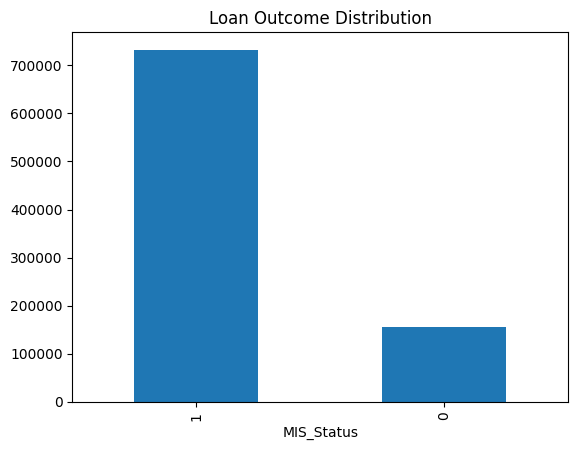

In [20]:
import matplotlib.pyplot as plt

df["MIS_Status"].value_counts().plot(kind="bar")
plt.title("Loan Outcome Distribution")
plt.show()

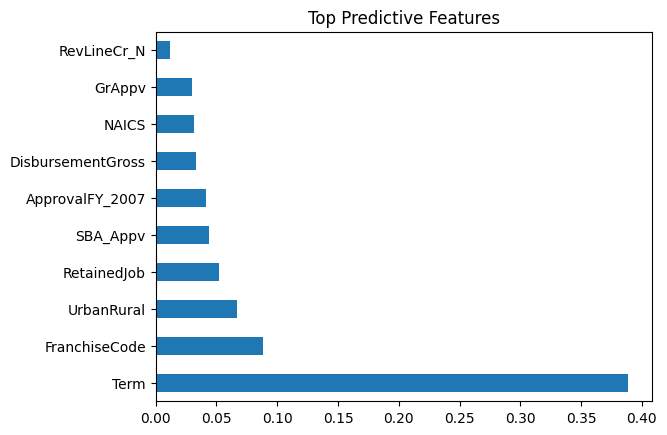

In [21]:
#feature importance
import pandas as pd 

importances = pd.Series(model.feature_importances_, index=X_train.columns)
importances.nlargest(10).plot(kind="barh")
plt.title("Top Predictive Features")
plt.show()

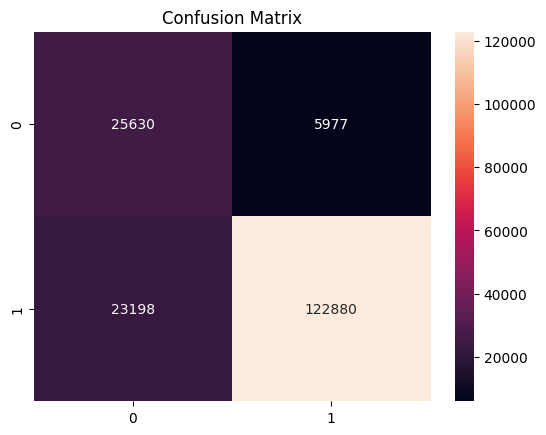

In [23]:
#confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, model.predict(X_test))
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.show()

In [24]:
import joblib
joblib.dump(model, "loan_risk_model.pkl")

['loan_risk_model.pkl']